# Redes Convolucionales (CNN)

Hoy vamos a clasificar **imágenes a color** con el dataset **CIFAR-10**:
60.000 fotos pequeñas de 10 categorías (aviones, coches, pájaros, gatos,
ciervos, perros, ranas, caballos, barcos y camiones).

El plan:
1. Explorar el dataset.
2. Probar una **red densa** y ver que se queda corta.
3. Construir una **CNN** y comprobar la mejora.
4. **Visualizar** qué detecta la red y dónde se equivoca.

> Activa la GPU en Colab: *Entorno de ejecución → Cambiar tipo de entorno → T4 GPU*.
> Con CIFAR-10 la GPU marca mucha diferencia.

## Importar y cargar CIFAR-10

Cada imagen es 32x32 píxeles con 3 canales de color (RGB)

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

print('TensorFlow', tf.__version__)
print('GPU disponible:', len(tf.config.list_physical_devices('GPU')))

(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
y_train = y_train.flatten()
y_test  = y_test.flatten()

clases = ['avión','coche','pájaro','gato','ciervo',
          'perro','rana','caballo','barco','camión']

print('Train:', X_train.shape, ' Test:', X_test.shape)

TensorFlow 2.21.0
GPU disponible: 0
Train: (50000, 32, 32, 3)  Test: (10000, 32, 32, 3)


## Mirar las imágenes

Antes de entrenar, siempre conviene ver con qué datos trabajamos.

Son fotos reales, a color y con fondos variados: mucho más difícil que MNIST.

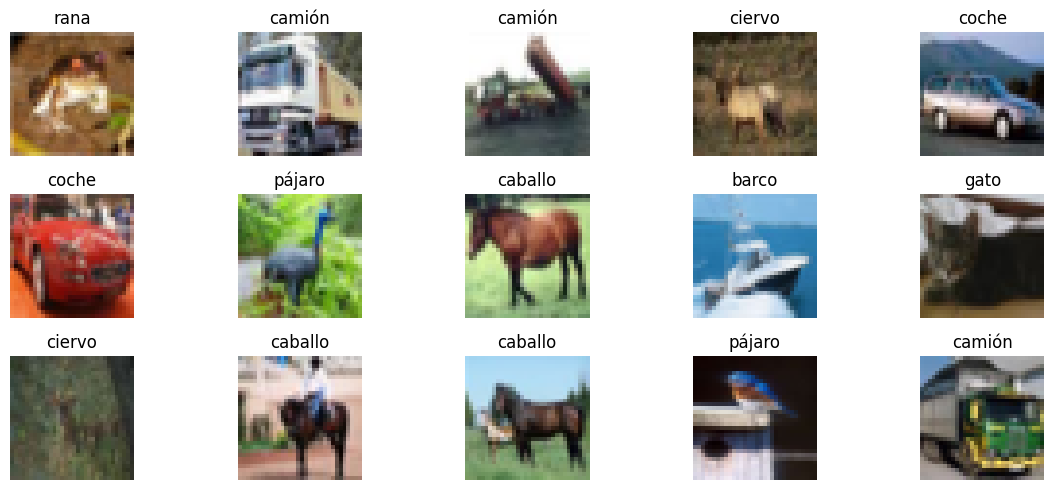

In [3]:
plt.figure(figsize=(12, 5))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_train[i])
    plt.title(clases[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

## Preparar los datos

Normalizamos los píxeles al rango 0-1 dividiendo por 255 (el valor máximo de color).

In [4]:
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32') / 255.0

print('Valores entre', X_train.min(), 'y', X_train.max())

Valores entre 0.0 y 1.0


## Intento 1: una red DENSA

Primero probamos con lo que ya conocemos: aplanamos la imagen y usamos
capas Dense. Veremos que el resultado es flojo: la red densa no entiende
la estructura de la imagen.

In [5]:
modelo_dense = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Flatten(),                       # 32x32x3 = 3072 valores
    layers.Dense(512, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
modelo_dense.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy', metrics=['accuracy'])
modelo_dense.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
hist_dense = modelo_dense.fit(X_train, y_train, epochs=10, batch_size=64,
                              validation_split=0.2, verbose=1)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.3219 - loss: 1.8885 - val_accuracy: 0.3812 - val_loss: 1.7194
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 26ms/step - accuracy: 0.3972 - loss: 1.6857 - val_accuracy: 0.3983 - val_loss: 1.7127
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - accuracy: 0.4249 - loss: 1.6099 - val_accuracy: 0.4234 - val_loss: 1.6280
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.4451 - loss: 1.5512 - val_accuracy: 0.4424 - val_loss: 1.5724
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 28ms/step - accuracy: 0.4549 - loss: 1.5191 - val_accuracy: 0.4550 - val_loss: 1.5464
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4714 - loss: 1.4752 - val_accuracy: 0.4603 - val_loss: 1.5202
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 28ms/step - accuracy: 0.4842 - loss: 1.4458 - val_accuracy: 0.4699 - val_loss: 1.5074
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - accuracy: 0.4927 - loss: 1.4238 - 

In [7]:
loss_d, acc_d = modelo_dense.evaluate(X_test, y_test, verbose=0)
print(f'\nRed densa — accuracy en test: {acc_d:.2%}')


Red densa — accuracy en test: 48.20%


Suele quedarse en torno al 45-50%. ¡Mejor que el azar (10%) pero pobre!

## Intento 2: una CNN

Ahora la red convolucional. Fíjate en la estructura:
- Bloques de **Conv2D + MaxPooling** que extraen características.
- Un **Flatten** que pasa de imagen a vector.
- Capas **Dense** que clasifican.

Argumentos de `Conv2D`:
- El primer número (32, 64...) es **cuántos filtros** usa (cuántos patrones busca).
- `(3, 3)` es el **tamaño del filtro**.
- `padding='same'` mantiene el tamaño tras la convolución.

In [8]:
modelo_cnn = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),

    # Bloque 1
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # Bloque 2
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # Bloque 3
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # Clasificación
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

In [9]:
modelo_cnn.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy', metrics=['accuracy'])
modelo_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Debería rondar el 70-75%: ¡un salto enorme frente a la red densa!

In [10]:
hist_cnn = modelo_cnn.fit(X_train, y_train, epochs=15, batch_size=64,
                          validation_split=0.2, verbose=1)

loss_c, acc_c = modelo_cnn.evaluate(X_test, y_test, verbose=0)
print(f'\nCNN — accuracy en test: {acc_c:.2%}')

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 40ms/step - accuracy: 0.3247 - loss: 1.8192 - val_accuracy: 0.4988 - val_loss: 1.4485
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.4691 - loss: 1.4655 - val_accuracy: 0.5680 - val_loss: 1.2193
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.5255 - loss: 1.3179 - val_accuracy: 0.5923 - val_loss: 1.1697
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.5633 - loss: 1.2234 - val_accuracy: 0.6383 - val_loss: 1.0389
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - accuracy: 0.5982 - loss: 1.1365 - val_accuracy: 0.6577 - val_loss: 0.9771
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.6187 - loss: 1.0840 - val_accuracy: 0.6707 - val_loss: 0.9342
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 34ms/step - accuracy: 0.6386 - loss: 1.0256 - val_accuracy: 0.6756 - val_loss: 0.9249
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 31ms/step - accuracy: 0.6525 - loss: 0.9810 - 

## Comparar densa vs CNN

Visualicemos la diferencia de accuracy entre las dos aproximaciones.

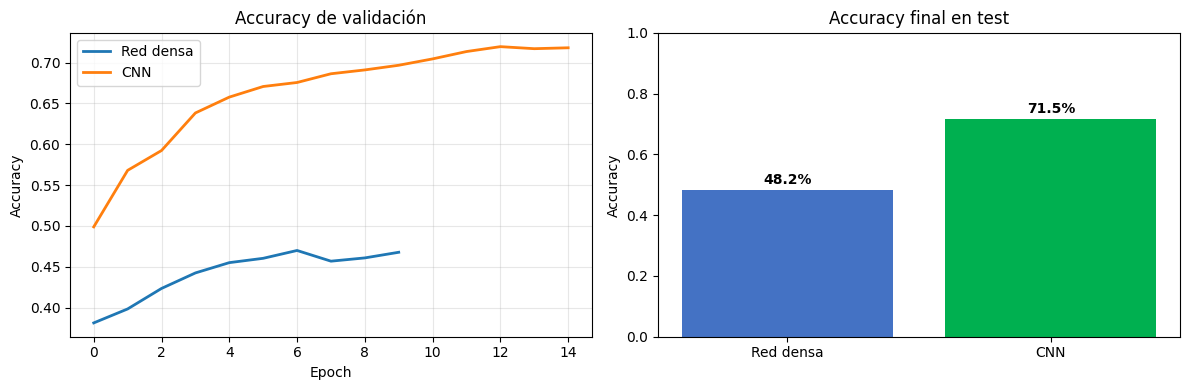

In [11]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(hist_dense.history['val_accuracy'], label='Red densa', linewidth=2)
plt.plot(hist_cnn.history['val_accuracy'], label='CNN', linewidth=2)
plt.title('Accuracy de validación')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.bar(['Red densa', 'CNN'], [acc_d, acc_c], color=['#4472C4', '#00B050'])
plt.title('Accuracy final en test'); plt.ylabel('Accuracy'); plt.ylim(0, 1)
for i, v in enumerate([acc_d, acc_c]):
    plt.text(i, v+0.02, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Ver las predicciones

Miramos algunas imágenes de test con la predicción de la CNN.
En verde los aciertos, en rojo los fallos.

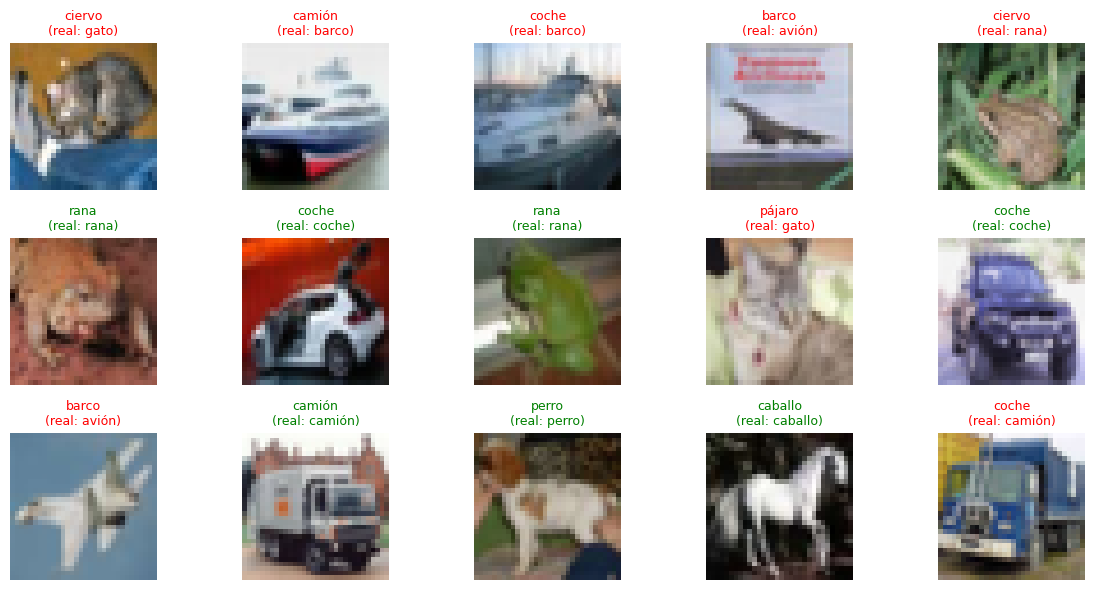

In [13]:
predicciones_dense = modelo_dense.predict(X_test[:15], verbose=0)

plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_test[i])
    pred = np.argmax(predicciones_dense[i])
    real = y_test[i]
    color = 'green' if pred == real else 'red'
    plt.title(f'{clases[pred]}\n(real: {clases[real]})', color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

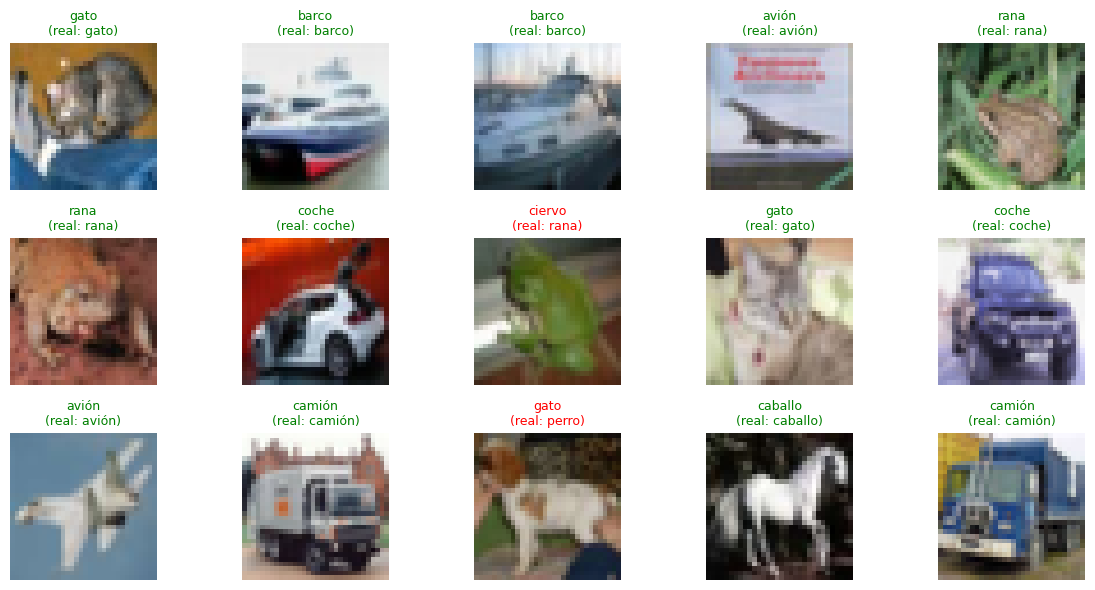

In [12]:
predicciones = modelo_cnn.predict(X_test[:15], verbose=0)

plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i+1)
    plt.imshow(X_test[i])
    pred = np.argmax(predicciones[i])
    real = y_test[i]
    color = 'green' if pred == real else 'red'
    plt.title(f'{clases[pred]}\n(real: {clases[real]})', color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## ¿Qué ve la red? (visualizar filtros)

Esto es lo más curioso: podemos ver los **mapas de características** que
genera la primera capa convolucional para una imagen. Cada mapa resalta
un patrón distinto (bordes, zonas claras, texturas...).

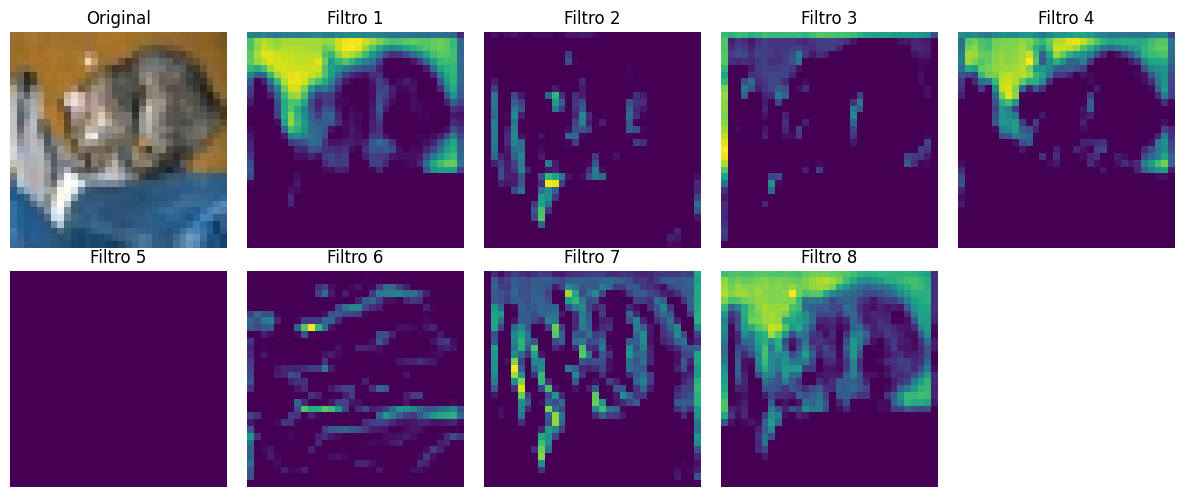

In [14]:

capa_conv = modelo_cnn.layers[0]
visualizador = keras.Model(inputs=modelo_cnn.inputs, outputs=capa_conv.output)

img = X_test[0:1]                   
mapas = visualizador.predict(img, verbose=0)[0]  

plt.figure(figsize=(12, 5))
plt.subplot(2, 5, 1)
plt.imshow(X_test[0]); plt.title('Original'); plt.axis('off')
for i in range(8):
    plt.subplot(2, 5, i+2)
    plt.imshow(mapas[:, :, i], cmap='viridis')
    plt.title(f'Filtro {i+1}'); plt.axis('off')
plt.tight_layout()
plt.show()